# Modelos Predictivos

Se importan todas las librerías necesarias

In [59]:
# Librerías de manipulación de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Machine Learning
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_absolute_error, make_scorer, r2_score, mean_squared_error

In [60]:
# Carga del dataset original
df = pd.read_csv('../data/processed/Spotify_2000_clean.csv')

print(f"✅ Dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas")
df.head()

✅ Dataset cargado: 1994 filas y 15 columnas


,index,title,artist,top_genre,year,beats_per_minute_bpm,energy,danceability,loudness_db,liveness,valence,length_duration,acousticness,speechiness,popularity
0,1,sunrise,norah jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,2,black night,deep purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,3,clint eastwood,gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,4,the pretender,foo fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,5,waitin' on a sunny day,bruce springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59


## Modelos de regresión


In [61]:
# Función para crear, evaluar y entrenar el modelo
def model(features, target, depth, est):
    
    # Detectar columnas categóricas y numéricas
    categorical_cols = features.select_dtypes(include=['object', 'category']).columns
    numerical_cols = features.select_dtypes(include=['int64', 'float64']).columns
    
    # Preprocesamiento
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])
    
    # Evaluación del modelo con validación cruzada
    scoring = {
        'r2': 'r2',  # Coeficiente de determinación r2
        'mae': make_scorer(mean_absolute_error),  # Error absoluto medio
        'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))  # Raíz del ECM
    }
    
    # Pipeline completo
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=est,
            max_depth=depth,
            random_state=9732
        ))
    ])
    
    # Evaluación del modelo
    results = cross_validate(pipeline, features, target, cv=5, scoring=scoring, return_train_score=True)
    results = pd.DataFrame(results)
    metrics = results[["test_r2", "test_mae", "test_rmse"]].mean()
    print(f"=== Métricas promedio en validación cruzada del concentrado ===")
    print(metrics.to_string(), "\n")
    
    # Entrenamiento del modelo
    pipeline.fit(features, target)
    
    return pipeline # Se regresa un pipeline ya ajustado

In [62]:
features = df.drop(columns=['index', 
                            'title', 
                            'artist',  
                            'popularity', 
                            'speechiness', 
                            'liveness', 
                            'beats_per_minute_bpm', 
                            'length_duration'])
target = df['popularity']
display(features.sample(5))
display(target.sample(5))

,top_genre,year,energy,danceability,loudness_db,valence,acousticness
505,dance pop,2012,28,61,-9,39,93
240,scottish singer-songwriter,2007,88,62,-5,86,27
1574,alternative rock,1992,39,57,-11,57,80
1160,album rock,1980,77,53,-6,76,0
340,belgian rock,2002,30,70,-17,23,4


1733    65
7       69
1463    74
1961    50
1382    49
Name: popularity, dtype: int64

In [63]:
modelo = model(features, target, depth=10, est=100)

/var/folders/z6/8g26l0dx1bq371hn2ggn9d480000gn/T/ipykernel_3855/3603350509.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = features.select_dtypes(include=['object', 'category']).columns


=== Métricas promedio en validación cruzada del concentrado ===
test_r2       0.174998
test_mae     10.268380
test_rmse    12.627929 



In [64]:
# Función para crear, evaluar y entrenar el modelo
def modelo_lightgbm(features, target):
    
    # Detectar columnas categóricas y numéricas
    categorical_cols = features.select_dtypes(include=['object', 'category']).columns
    
    # Convertir columnas categóricas a tipo 'category' para LightGBM
    features_lgbm = features
    for col in categorical_cols:
        features_lgbm[col] = features_lgbm[col].astype("category")
    
    # Evaluación del modelo con validación cruzada
    scoring = {
        'r2': 'r2',  # Coeficiente de determinación r2
        'mae': make_scorer(mean_absolute_error),  # Error absoluto medio
        'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))  # Raíz del ECM
    }
    
    # Modelo LightGBM
    model_lgbm = LGBMRegressor(
    objective='regression',
    n_estimators=500, 
    learning_rate=0.01,
    max_depth=5,
    random_state=9732,
    verbose=-1
)
    
    # Evaluación del modelo
    results = cross_validate(model_lgbm, features_lgbm, target, cv=5, scoring=scoring, return_train_score=True)
    results = pd.DataFrame(results)
    metrics = results[["test_r2", "test_mae", "test_rmse"]].mean()
    print(f"=== Métricas promedio en validación cruzada del concentrado ===")
    print(metrics.to_string(), "\n")
    
    # Entrenamiento del modelo
    model_lgbm.fit(features_lgbm, target)
    
    return model_lgbm # Se regresa el modelo ya ajustado

In [65]:
modelo_2 = modelo_lightgbm(features, target)

/var/folders/z6/8g26l0dx1bq371hn2ggn9d480000gn/T/ipykernel_3855/2508517994.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = features.select_dtypes(include=['object', 'category']).columns


=== Métricas promedio en validación cruzada del concentrado ===
test_r2       0.191050
test_mae     10.090984
test_rmse    12.474981 



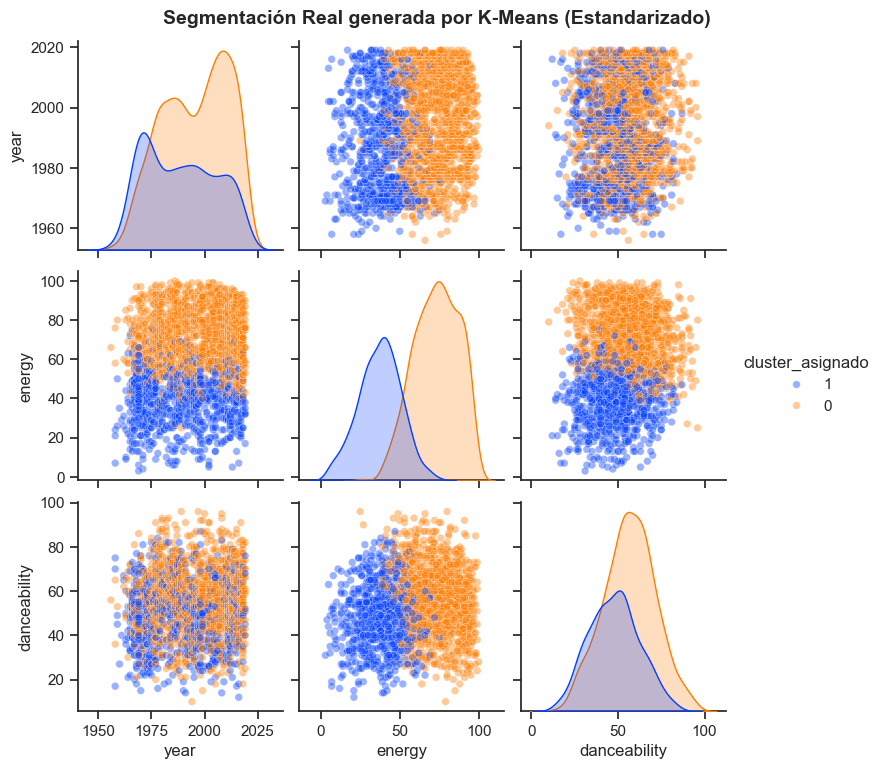

In [ ]:
# 1. Preparar y limpiar las variables como lo hiciste
df_kmeans = df.copy()
columnas_a_eliminar = ['index', 'title', 'artist', 'top_genre', 'popularity', 
                        'speechiness', 'liveness', 'beats_per_minute_bpm', 'length_duration']

# Elimnar solo las columnas que existen para evitar errores
df_kmeans = df_kmeans.drop(columns=[col for col in columnas_a_eliminar if col in df_kmeans.columns])

# 2. CRUCIAL: Escalar los datos (Media = 0, Varianza = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_kmeans)

# 3. Entrenar el modelo K-Means
n_clusters = 2  # Mantenemos 2 clústeres (Premium vs Normal)
model = KMeans(n_clusters=n_clusters, random_state=12345, n_init=10)
df['cluster_asignado'] = model.fit_predict(X_scaled) # Guardamos la predicción en el df original

# Convertir el clúster a tipo string/categoría para que seaborn lo trate como etiquetas discretas
df['cluster_asignado'] = df['cluster_asignado'].astype(str)

# 4. VISUALIZACIÓN ENFOCADA EN LOS CLÚSTERES
# Seleccionamos solo 3 o 4 variables clave para que el pairplot sea legible de un vistazo
variables_interes = ['year', 'energy', 'danceability', 'loudness', 'cluster_asignado']
variables_existentes = [col for col in variables_interes if col in df.columns]

sns.set_theme(style="ticks")
pairgrid = sns.pairplot(
    data=df[variables_existentes], 
    hue='cluster_assigned' if 'cluster_assigned' in variables_existentes else 'cluster_asignado', 
    palette='bright',
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 30} # Puntos un poco transparentes para ver la densidad
)

plt.suptitle('Segmentación Real generada por K-Means (Estandarizado)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

In [67]:
# Corre esto para ver la relación con la puntuación
print(df.groupby('cluster_asignado')['popularity'].describe())

                   count       mean        std   min    25%   50%   75%    max
cluster_asignado                                                              
0                 1246.0  60.626806  14.327592  12.0  51.00  63.0  72.0  100.0
1                  748.0  57.693850  14.212995  11.0  48.75  59.0  69.0   98.0


In [68]:
# Analizar qué significa cada clúster respecto a la popularidad original
perfil_clusters = df.groupby('cluster_asignado').agg(
    total_canciones=('popularity', 'count'),
    popularidad_promedio=('popularity', 'mean'),
    energia_promedio=('energy', 'mean'),
    babilidad_promedio=('danceability', 'mean')
)
print(perfil_clusters)

                  total_canciones  popularidad_promedio  energia_promedio  \
cluster_asignado                                                            
0                            1246             60.626806         73.120385   
1                             748             57.693850         37.290107   

                  babilidad_promedio  
cluster_asignado                      
0                          56.544944  
1                          47.729947  


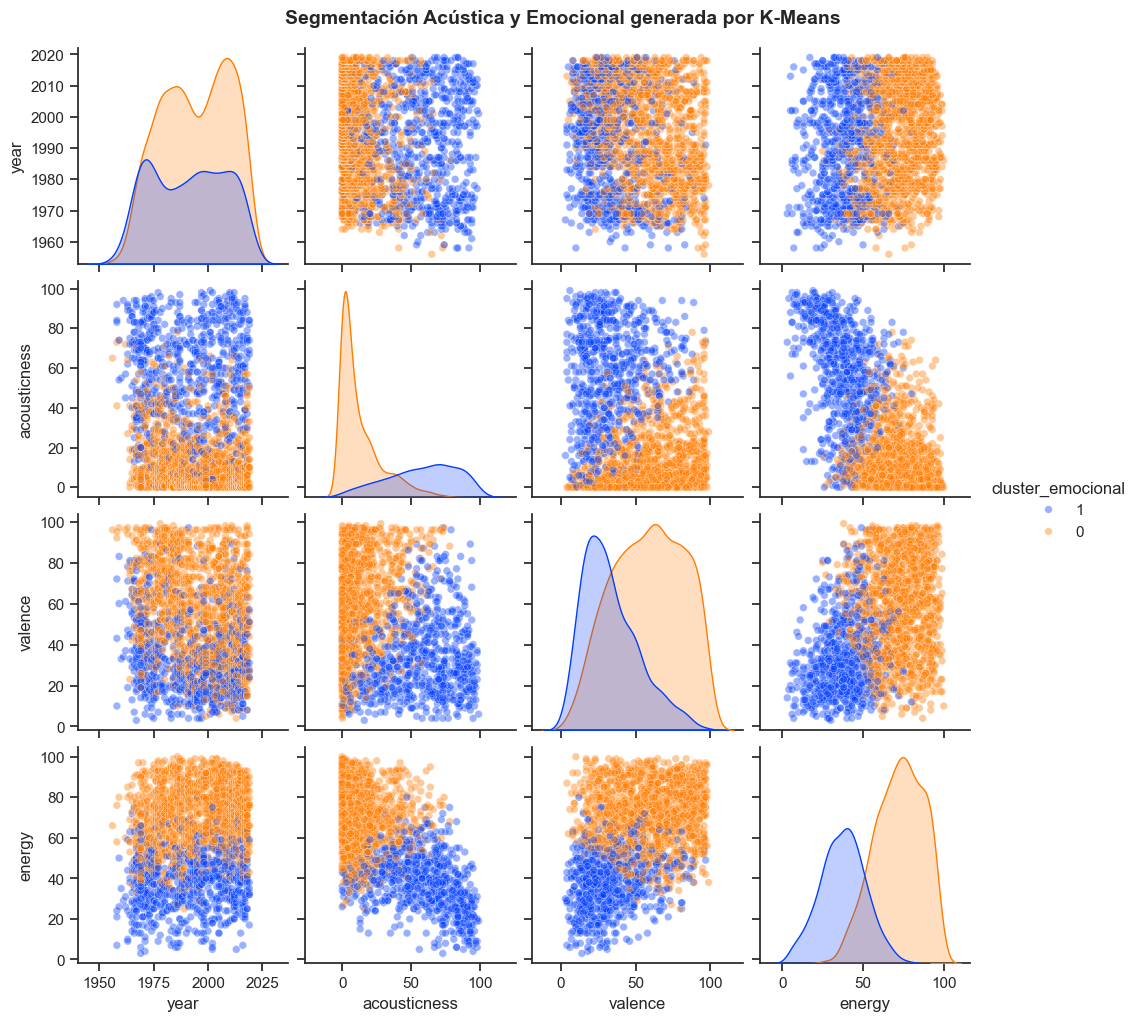

In [ ]:
# 1. Preparar las variables específicas para este nuevo análisis
df_kmeans_2 = df.copy()

# Nos quedamos con el bloque acústico/emocional clave y controlamos el tiempo
variables_nuevas = ['year', 'acousticness', 'valence', 'energy']
variables_disponibles = [col for col in variables_nuevas if col in df_kmeans_2.columns]

X_raw = df_kmeans_2[variables_disponibles]

# 2. Escalar los datos 
scaler_2 = StandardScaler()
X_scaled_2 = scaler_2.fit_transform(X_raw)

# 3. Entrenar el nuevo modelo K-Means
n_clusters = 2
model_2 = KMeans(n_clusters=n_clusters, random_state=12345, n_init=10)

# Guardamos el nuevo clúster con un nombre diferente para no encimarlo con el anterior
df['cluster_emocional'] = model_2.fit_predict(X_scaled_2).astype(str)

# 4. Visualizar la segmentación acústica-emocional
sns.set_theme(style="ticks")
pairgrid_2 = sns.pairplot(
    data=df[variables_disponibles + ['cluster_emocional']], 
    hue='cluster_emocional', 
    palette='bright', # Paleta segura y estándar
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 30}
)

plt.suptitle('Segmentación Acústica y Emocional generada por K-Means', y=1.02, fontsize=14, fontweight='bold')
plt.show()

In [ ]:
def modelo_optimizado(features, target, depth, est):
    # 1. Filtrar o agrupar categorías con alta cardinalidad antes de procesar
    
    categorical_cols = features.select_dtypes(include=['object', 'category']).columns
    numerical_cols = features.select_dtypes(include=['int64', 'float64']).columns
    
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])
    
    scoring = {
        'r2': 'r2',
        'mae': make_scorer(mean_absolute_error),
        'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
    }
    
    # Incrementamos min_samples_split para evitar que el árbol memorice ruido (regularización)
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=est,
            max_depth=depth,
            min_samples_split=5,  # <- Ayuda a reducir el overfitting en datasets ruidosos
            random_state=9732,
            n_jobs=-1             
        ))
    ])
    
    results = cross_validate(pipeline, features, target, cv=5, scoring=scoring, return_train_score=True)
    results = pd.DataFrame(results)
    
    # Imprimir métricas de Test vs Train para detectar Overfitting
    print(f"=== Métricas Promedio (Validación Cruzada) ===")
    print(f"R² Test:  {results['test_r2'].mean():.4f}  |  R² Train: {results['train_r2'].mean():.4f}")
    print(f"MAE Test: {results['test_mae'].mean():.4f}  |  MAE Train: {results['train_mae'].mean():.4f}")
    print(f"RMSE Test:{results['test_rmse'].mean():.4f}  |  RMSE Train: {results['train_rmse'].mean():.4f}\n")
    
    pipeline.fit(features, target)
    return pipeline

In [71]:
df_model = df.copy()

df_model['decade'] = (df_model['year'] // 10) * 10
df_model['decade'] = df_model['decade'].astype(str) + 's'


# Crear antes de meter los datos al modelo
df_model['energy_z_decade'] = df_model.groupby('decade')['energy'].transform(lambda x: (x - x.mean()) / x.std())

features = df_model.drop(columns=['index', 
                            'title', 
                            'artist',
                            'top_genre',  
                            'popularity', 
                            'speechiness', 
                            'liveness', 
                            'beats_per_minute_bpm', 
                            'length_duration'])
target = df_model['popularity']
display(features.sample(5))
display(target.sample(5))

,year,energy,danceability,loudness_db,valence,acousticness,cluster_asignado,cluster_emocional,decade,energy_z_decade
1542,1991,37,53,-13,25,8,1,1,1990s,-1.018286
29,2004,70,68,-10,51,8,0,0,2000s,0.264651
1836,1963,9,36,-18,19,92,1,1,1960s,-1.950048
575,2014,71,33,-7,19,31,0,0,2010s,0.477232
688,2017,78,78,-4,67,6,0,0,2010s,0.814934


398     84
252     47
1510    73
1824    72
1039    66
Name: popularity, dtype: int64

In [72]:
modelo = modelo_optimizado(features, target, depth=10, est=100)

/var/folders/z6/8g26l0dx1bq371hn2ggn9d480000gn/T/ipykernel_3855/489515362.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = features.select_dtypes(include=['object', 'category']).columns


=== Métricas Promedio (Validación Cruzada) ===
R² Test:  0.0361  |  R² Train: 0.6496
MAE Test: 11.1949  |  MAE Train: 6.8402
RMSE Test:13.7026  |  RMSE Train: 8.4634



In [ ]:
pipeline_objeto = modelo

# Extraemos los componentes directamente del pipeline cargado
preprocessor_objeto = pipeline_objeto.named_steps['preprocessor']
modelo_rf = pipeline_objeto.named_steps['model']

# Obtener los nombres de las columnas después del preprocesamiento
cat_features = list(preprocessor_objeto.named_transformers_['cat'].get_feature_names_out())
num_features = list(preprocessor_objeto.named_transformers_['num'].feature_names_in_)
todas_las_features = num_features + cat_features

# Crear el DataFrame de importancia
importancias = pd.DataFrame({
    'Variable': todas_las_features,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("=== IMPORTANCIA DE LAS VARIABLES ===")
print(importancias.head(10))

=== IMPORTANCIA DE LAS VARIABLES ===
           Variable  Importancia
0              year     0.220415
2      danceability     0.161319
3       loudness_db     0.147067
4           valence     0.141574
5      acousticness     0.116788
6   energy_z_decade     0.102350
1            energy     0.082368
14     decade_1980s     0.007449
16     decade_2000s     0.005244
17     decade_2010s     0.003877


In [ ]:
df_model = df.copy()

# 1. Configurar bloques temporales
df_model['decade'] = (df_model['year'] // 10) * 10
df_model['decade'] = df_model['decade'].astype(str) + 's'

# Asegurar que los clústeres sean tratados como categorías explícitas
df_model['cluster_asignado'] = df_model['cluster_asignado'].astype('object')
df_model['cluster_emocional'] = df_model['cluster_emocional'].astype('object')

# 2. CREAR EL NUEVO TARGET: Éxito relativo en su década
df_model['popularity_z_decade'] = df_model.groupby('decade')['popularity'].transform(lambda x: (x - x.mean()) / x.std())
target_z = df_model['popularity_z_decade'] # <- NUEVO TARGET

# 3. Crear variables acústicas relativas
df_model['energy_z_decade'] = df_model.groupby('decade')['energy'].transform(lambda x: (x - x.mean()) / x.std())

# 4. Seleccionar características (Eliminamos COMPLETAMENTE cualquier rastro de popularidad bruta)
features_z = df_model.drop(columns=[
    'index', 'title', 'artist', 'top_genre', 
    'popularity', 'popularity_z_decade', # <- Eliminadas del set de entrenamiento
    'speechiness', 'liveness', 'beats_per_minute_bpm', 'length_duration'
])

print("Variables que entrarán al modelo:")
print(features_z.columns.tolist())

# 5. Entrenar el modelo con el nuevo target balanceado
mi_pipeline_z = modelo_optimizado(features_z, target_z, depth=6, est=150) # Reduce depth para evitar overfitting

Variables que entrarán al modelo:
['year', 'energy', 'danceability', 'loudness_db', 'valence', 'acousticness', 'cluster_asignado', 'cluster_emocional', 'decade', 'energy_z_decade']


/var/folders/z6/8g26l0dx1bq371hn2ggn9d480000gn/T/ipykernel_3855/489515362.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = features.select_dtypes(include=['object', 'category']).columns


=== Métricas Promedio (Validación Cruzada) ===
R² Test:  0.0464  |  R² Train: 0.2893
MAE Test: 0.7973  |  MAE Train: 0.6874
RMSE Test:0.9742  |  RMSE Train: 0.8415



In [ ]:
# Pasamos el pipeline a una variable
pipeline_objeto = mi_pipeline_z

# Extraemos los componentes directamente del pipeline cargado
preprocessor_objeto = pipeline_objeto.named_steps['preprocessor']
modelo_rf = pipeline_objeto.named_steps['model']

# Obtener los nombres de las columnas después del preprocesamiento
cat_features = list(preprocessor_objeto.named_transformers_['cat'].get_feature_names_out())
num_features = list(preprocessor_objeto.named_transformers_['num'].feature_names_in_)
todas_las_features = num_features + cat_features

# Crear el DataFrame de importancia
importancias = pd.DataFrame({
    'Variable': todas_las_features,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("=== IMPORTANCIA DE LAS VARIABLES ===")
print(importancias.head(10))

=== IMPORTANCIA DE LAS VARIABLES ===
           Variable  Importancia
3       loudness_db     0.240400
0              year     0.182670
2      danceability     0.180874
6   energy_z_decade     0.114382
4           valence     0.100761
5      acousticness     0.089756
1            energy     0.059964
15     decade_1990s     0.007715
16     decade_2000s     0.006863
14     decade_1980s     0.005524
